# Image captioning with attention-based custom LSTM Decoder
### Setup: Runtime > Change type to T4 GPU > Run all cells in order
### Should take around 70 minutes to run on T4

In [3]:
import os, zipfile

if not os.path.exists('data/images/Flicker8k_Dataset'):
    print("Downloading dataset")
    os.makedirs('data/images', exist_ok=True)
    os.makedirs('data/text', exist_ok=True)
    os.makedirs('checkpoints', exist_ok=True)
    os.system('wget -q --show-progress "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip" -O data/images.zip')
    os.system('wget -q --show-progress "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip" -O data/text.zip')
    with zipfile.ZipFile('data/images.zip') as zip:
        z.extractall('data/images')
    with zipfile.ZipFile('data/text.zip') as zip:
        z.extractall('data/text')
    print("Dataset donwloaded")
else:
    print("Data exists.")

os.makedirs('checkpoints', exist_ok=True)
print("Images:", len(os.listdir('data/images/Flicker8k_Dataset')))

Data exists.
Images: 8091


In [24]:
IMGDIR = os.path.abspath('data/images/Flicker8k_Dataset')
CAP_FILE = os.path.abspath('data/text/Flickr8k.token.txt')
CPOINT_DIR = 'checkpoints'

F_THRESHOLD = 5
EMBED_DIM = 256
TextGen_DIM = 512
ENCODER_DIM = 2048
ATTN_DIM = 256
DROPOUT = 0.3
BATCH_SIZE = 64
EPOCHS = 10
LR = 4e-4
GRAD_CLIP = 5.0
NUM_WORKERS = 0
MAX_CAPTION_LEN = 50

In [5]:
from collections import Counter

class Vocabulary:
  def __init__(self, F_THRESHOLD=5):

    self.F_THRESHOLD = F_THRESHOLD
    self.wToIndx = {"<PAD>":0, "<START>":1, "<END>":2, "<UNK>":3}
    self.indxToW = {v: k for k, v in self.wToIndx.items()}
    self.n_indx = 4

  def build(self, captions):
    counts = Counter()
    for cap in captions:
      for word in cap.lower().split():
        counts[word] += 1
    for word, freq in counts.items():
      if freq >= self.F_THRESHOLD:
        self.wToIndx[word] = self.n_indx
        self.indxToW[self.n_indx] = word
        self.n_indx += 1
    print(f"Vocabulary: {len(self)} words")

  def encode(self, caption):
    tokens = caption.lower().split()
    return (
        [self.wToIndx["<START>"]]
      + [self.wToIndx.get(t, self.wToIndx["<UNK>"]) for t in tokens]
      + [self.wToIndx["<END>"]]
    )

  def decode(self, tokens):
    return " ".join(self.indxToW.get(i, "<UNK>")
    for i in tokens if i not in (0,1,2))

  def __len__(self):
    return self.n_indx


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from PIL import Image
import torchvision.transforms as T

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class CapDataset(Dataset):
  def __init__(self, IMGDIR, CAP_FILE, vocab):
    self.IMGDIR = IMGDIR
    self.vocab = vocab
    self.data = []
    with open(CAP_FILE) as f:
      for line in f:
        line = line.strip()
        if not line:
          continue
        img_id, caption = line.split('\t')
        self.data.append((img_id, caption))

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
      img_id, caption = self.data[idx]
      img_name = img_id.split("#")[0]
      if img_name.endswith('.jpg.1'):
          img_name = img_name.replace('.jpg.1', '.jpg')
      img_path = os.path.join(self.IMGDIR, img_name)

      if not os.path.exists(img_path):
          return self.__getitem__((idx + 1) % len(self.data))

      img = Image.open(img_path).convert('RGB')
      img = transform(img)
      ids = torch.tensor(self.vocab.encode(caption), dtype=torch.long)
      return img, ids

def pack_batch(batch):
  imgs, captions = zip(*batch)
  imgs = torch.stack(imgs, dim=0)
  captions = pad_sequence(captions, batch_first=True, padding_value=0)
  return imgs, captions

In [7]:
import torch.nn as nn
import torchvision.models as models

class Encoder(nn.Module):
  def __init__(self, encoded_image_size=7):
    super().__init__()
    resnet = models.resnet50(weights='IMAGENET1K_V1')
    self.resnet = nn.Sequential(*list(resnet.children())[:-2])
    self.pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))

    for p in self.resnet.parameters():
      p.requires_grad = False

  def forward(self, imgs):
    out = self.resnet(imgs)
    out = self.pool(out)
    out = out.permute(0, 2, 3, 1)
    B, H, W, C = out.shape
    return out.view(B, H * W, C)

In [8]:
class Attention(nn.Module):
  def __init__(self, encoder_dim, TextGen_dim, attn_dim):
    super().__init__()
    self.encoder_att = nn.Linear(encoder_dim, attn_dim)
    self.TextGen_att = nn.Linear(TextGen_dim, attn_dim)
    self.full_attn = nn.Linear(attn_dim, 1)

  def forward(self, features, hidden):
    e = self.encoder_att(features)
    d = self.TextGen_att(hidden).unsqueeze(1)
    scores = self.full_attn(torch.tanh(e+d))
    weights = torch.softmax(scores, dim=1)
    context = (weights * features).sum(dim=1)
    return context, weights.squeeze(2)

In [9]:
class LSTM(nn.Module):
  def __init__(self, input_size, hidden_size):
    super().__init__()
    self.hidden_size = hidden_size
    self.forget_gate = nn.Linear(input_size + hidden_size, hidden_size)
    self.input_gate = nn.Linear(input_size + hidden_size, hidden_size)
    self.cell_gate = nn.Linear(input_size + hidden_size, hidden_size)
    self.output_gate = nn.Linear(input_size + hidden_size, hidden_size)

  def forward(self, x, h_prev, c_prev):
    combined = torch.cat([h_prev, x], dim=1)
    f = torch.sigmoid(self.forget_gate(combined))
    i = torch.sigmoid(self.input_gate(combined))
    g = torch.tanh(self.cell_gate(combined))
    o = torch.sigmoid(self.output_gate(combined))
    c = f * c_prev + i * g
    h = o * torch.tanh(c)
    return h, c

In [16]:
class Generator(nn.Module):
  def __init__ (self, vocab_size):
    super().__init__()
    self.attention = Attention(ENCODER_DIM, TextGen_DIM, ATTN_DIM)
    self.embedding = nn.Embedding(vocab_size, EMBED_DIM)
    self.dropout = nn.Dropout(DROPOUT)
    self.lstm_cell = LSTM(EMBED_DIM + ENCODER_DIM, TextGen_DIM)
    self.fc_out = nn.Linear(TextGen_DIM, vocab_size)
    self.init_h = nn.Linear(ENCODER_DIM, TextGen_DIM)
    self.init_c = nn.Linear(ENCODER_DIM, TextGen_DIM)

  def init_hidden(self, features):
    mean = features.mean(dim=1)
    return torch.relu(self.init_h(mean)), torch.relu(self.init_c(mean))

  def forward_step(self, tok, h, c, features):
    emb = self.dropout(self.embedding(tok))
    context, weights = self.attention(features, h)
    h, c = self.lstm_cell(torch.cat([emb, context], dim=1), h, c)
    scores = self.fc_out(self.dropout(h))
    return scores, h, c, weights


  def forward(self, features, captions):
    B, T = captions.shape
    h, c = self.init_hidden(features)
    preds, weightss = [], []
    for i in range (T - 1):
      scores, h, c, a = self.forward_step(
          captions[:, i], h, c, features
      )
      preds.append(scores)
      weightss.append(a)
    return torch.stack(preds, dim=1), torch.stack(weightss, dim=1)


In [17]:
vocab = Vocabulary(F_THRESHOLD=F_THRESHOLD)
caps = []
with open(CAP_FILE) as f:
  for line in f:
    line = line.strip()
    if line:
      _, caption = line.split('\t')
      caps.append(caption)
vocab.build(caps)

dataset = CapDataset(IMGDIR, CAP_FILE, vocab)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=pack_batch, num_workers=NUM_WORKERS)
print(f"Dataset size: {len(dataset)}")
print(f"Batches per epoch: {len(loader)}")


Vocabulary: 3005 words
Dataset size: 40460
Batches per epoch: 633


In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Prog Is using", device)
encoder = Encoder().to(device)
TextGen = Generator(vocab_size=len(vocab)).to(device)

imgs, captions = next(iter(loader))
imgs, captions = imgs.to(device), captions.to(device)

with torch.no_grad():
  feats = encoder(imgs)

preds, weightss = TextGen(feats, captions)
print(f"feats: {feats.shape}")
print(f"preds: {preds.shape}")
print(f"weightss: {weightss.shape}")

Prog Is using cuda
feats: torch.Size([64, 49, 2048])
preds: torch.Size([64, 23, 3005])
weightss: torch.Size([64, 23, 49])


In [20]:
import torch.optim as optim

optimizer = optim.Adam(TextGen.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=0)

for epoch in range(1, EPOCHS + 1):
  encoder.eval()
  TextGen.train()
  batchLoss = 0

  for imgs, captions in loader:
    imgs, captions = imgs.to(device), captions.to(device)

    with torch.no_grad():
      features = encoder(imgs)


    preds, weightss = TextGen(features, captions)

    loss = criterion(
        preds.view(-1, len(vocab)),
        captions[:, 1:].reshape(-1)
    )

    loss += 1.0 * ((1 - weightss.sum(dim=1)) ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(TextGen.parameters(), GRAD_CLIP)
    optimizer.step()
    batchLoss += loss.item()

  avg = batchLoss / len(loader)
  print(f"Epoch: {epoch}, Loss: {avg:.4f}")

  torch.save({
      'epoch': epoch,
      'TextGen': TextGen.state_dict(),
      'encoder': encoder.state_dict(),
      'vocab': vocab
  }, f"{CPOINT_DIR}/checkpoint_{epoch}.pth")


Epoch: 1, Loss: 4.1190
Epoch: 2, Loss: 3.3718
Epoch: 3, Loss: 3.1249
Epoch: 4, Loss: 2.9736
Epoch: 5, Loss: 2.8648
Epoch: 6, Loss: 2.7755
Epoch: 7, Loss: 2.7017
Epoch: 8, Loss: 2.6374
Epoch: 9, Loss: 2.5783
Epoch: 10, Loss: 2.5313


In [21]:
def generate_caption(encoder, TextGen, img, vocab, max_len=MAX_CAPTION_LEN):
  encoder.eval()
  TextGen.eval()
  with torch.no_grad():
    enc = encoder(img.unsqueeze(0).to(device))
    h, c = TextGen.init_hidden(enc)
    tok = torch.tensor([vocab.wToIndx['<START>']]).to(device)
    words = []

    for _ in range(max_len):
      scores, h, c, _ = TextGen.forward_step(tok, h, c, enc)
      tok = scores.argmax(dim=1)
      word = vocab.indxToW.get(tok.item(), '<UNK>')
      if word == '<END>':
        break
      if word not in ("<PAD>", "<START>"):
        words.append(word)
  return " ".join(words)

img, _ = dataset[0]
Result = generate_caption(encoder, TextGen, img, vocab)

In [22]:
from nltk.translate.bleu_score import corpus_bleu
import nltk
nltk.download('punkt_tab', quiet = True)

def evaluate_bleu(n=500):
    refs, hyps = [], []
    for i in range(n):
        img, caption_ids = dataset[i]
        ref = vocab.decode(caption_ids.tolist()).split()
        hyp = generate_caption(encoder, TextGen, img, vocab).split()
        refs.append([ref])
        hyps.append(hyp)
    bleu4 = corpus_bleu(refs, hyps)
    print(f"BLEU-4: {bleu4:.4f}")
    return bleu4

evaluate_bleu()

BLEU-4: 0.1142


0.11422464007765507

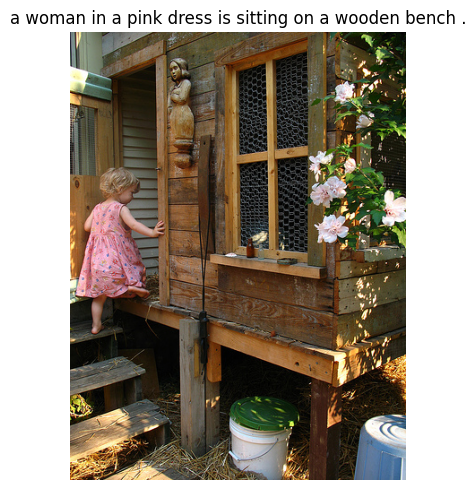

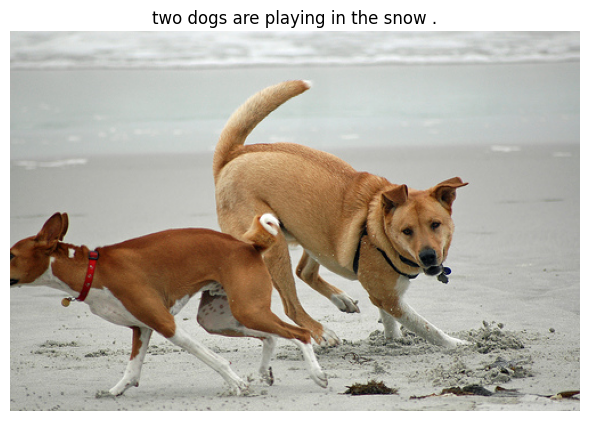

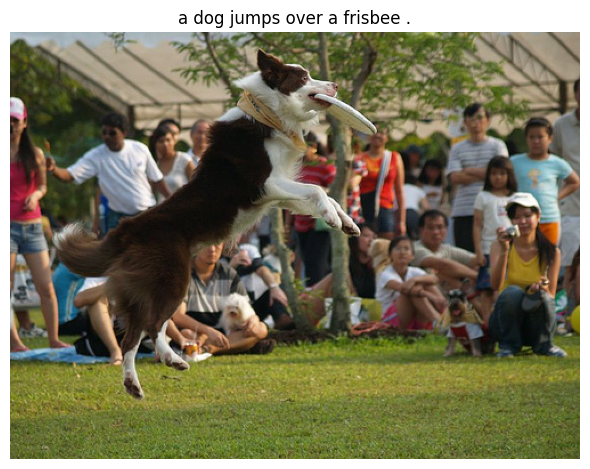

In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

def show_caption(idx):
    img_id, _ = dataset.data[idx]
    img_name = img_id.split('#')[0]
    img_path = os.path.join(IMGDIR, img_name)


    img_tensor, _ = dataset[idx]
    generated = generate_caption(encoder, TextGen, img_tensor, vocab)

    img = mpimg.imread(img_path)
    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(generated, fontsize=12, wrap=True)
    plt.tight_layout()
    plt.show()

for i in [0, 100, 500]:
    show_caption(i)